<h1 align="center">Portfolio Management and Optimization</h1>

#### Introduction 

Portfolio management, as an important branch of finance, allows investors to manage their invested funds through strategies designed to achieve expected levels of return while controlling equivalent levels of risk, rather than leaving their wealth subject to chance and speculation.

In this modest study, we will compare the statistical properties of asset prices and returns in order to determine which is more effective for portfolio management. Furthermore, we will explore different portfolio opportunities composed of multiple risky assets by projecting them onto a risk-return plane, with the aim of identifying the optimal positions for a rational investor.

Let us begin by importing all the Python libraries that will be used throughout this study.


In [2]:
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

#### I. Statistical Study (Prices vs. Returns)

At the outset, it is essential to import the data on which our study will be conducted. Specifically, we will use the daily closing prices of the “Tesla” stock over the entire year 2020.

##### 1. Data Import 

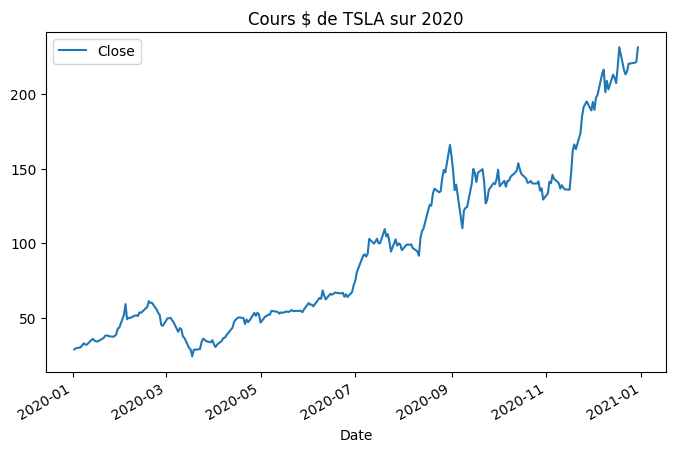

In [3]:
tsla = yf.Ticker("TSLA")
tsla_data = tsla.history(start='2020-01-01', end='2020-12-31')
tsla_df = tsla_data[['Close']]

tsla_df.plot(figsize=(8,5), title='Cours $ de TSLA sur 2020')
plt.show()

##### Returns Series

We are interested in constructing the column of daily log-returns of the asset by computing $\log(S_t / S_{t-1})$ for each price observation.


C:\Users\abede\AppData\Local\Temp\ipykernel_21584\3966825289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsla_df['Rendement (%)'] = np.log(tsla_df['Close'] / tsla_df['Close'].shift(1)) * 100


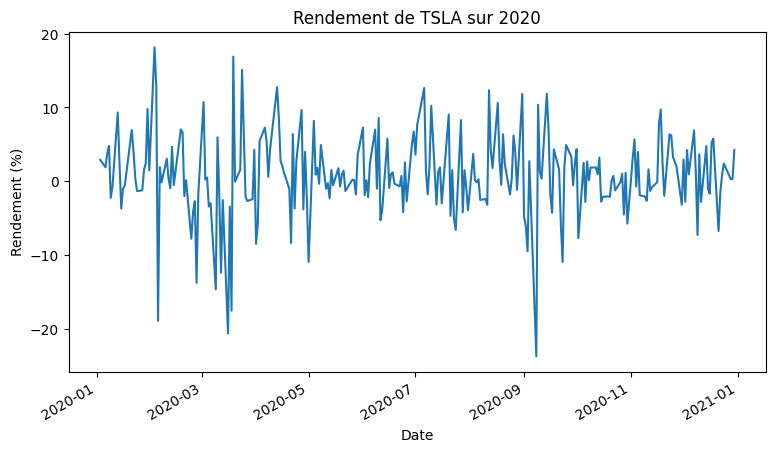

In [4]:
tsla_df['Rendement (%)'] = np.log(tsla_df['Close'] / tsla_df['Close'].shift(1)) * 100
tsla_df = tsla_df.iloc[1: , :]

#Tracer la courbe des rendements
tsla_df['Rendement (%)'].plot(figsize=(9,5), title='Rendement de TSLA sur 2020')
plt.ylabel('Rendement (%)')
plt.show()

#### 2.Extraction of Statistical Properties

We now examine the descriptive statistics of both series: the closing prices (*Close*) and the returns (%). This will allow us to compare their central tendency, dispersion, and overall statistical behavior.


In [5]:
tsla_df.describe().round(3)

,Close,Rendement (%)
count,251.000,251.000
mean,96.385,0.832
std,55.707,5.660
min,24.081,-23.652
25%,49.949,-2.007
50%,80.577,0.743
75%,140.363,3.852
max,231.667,18.145


The dataset contains 251 observations of both prices and returns over the year 2020. It can be observed that the maximum daily increase in the stock price was 18.145%, while the maximum daily decrease was -23.653%. However, on average, the asset generated a daily return of approximately 0.819%.


##### 2.1. Stationarity

In order to test the stationarity of the two studied series, we will use the **Augmented Dickey-Fuller** (ADF) test.

Below is our custom function, which displays the test results as well as the critical values used to assess the stationarity hypothesis.


In [6]:
from statsmodels.tsa.stattools import adfuller
def DFtest(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic',
                                             'p-value','Lags Used',
                                             'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [7]:
DFtest(tsla_df['Close'])

Results of Dickey-Fuller Test:
Test Statistic                   0.725376
p-value                          0.990331
Lags Used                        0.000000
Number of Observations Used    250.000000
Critical Value (1%)             -3.456781
Critical Value (5%)             -2.873172
Critical Value (10%)            -2.572969
dtype: float64


Regarding the price series, the **Augmented Dickey-Fuller** test statistic is 0.72838. This value is higher than the critical values, indicating a lack of evidence in favor of stationarity. In addition, the p-value is 0.99, which is significantly greater than the 0.05 significance level. Therefore, we fail to reject the null hypothesis of a unit root, meaning that the series is non-stationary.


In [8]:
DFtest(tsla_df['Rendement (%)'])

Results of Dickey-Fuller Test:
Test Statistic                -1.575188e+01
p-value                        1.220556e-28
Lags Used                      0.000000e+00
Number of Observations Used    2.500000e+02
Critical Value (1%)           -3.456781e+00
Critical Value (5%)           -2.873172e+00
Critical Value (10%)          -2.572969e+00
dtype: float64


For the returns series, the Augmented Dickey-Fuller test statistic is -15.703, which is lower than the critical values, providing strong evidence against the presence of a unit root. In addition, the p-value is 1.28 × 10⁻²⁸, which is far below the 0.05 significance level. Therefore, we reject the null hypothesis of non-stationarity and conclude that the returns series is stationary.


##### 2.2. Autocorrelation
To verify the presence of autocorrelation in both series, we will examine their correlograms, which represent the values of
$\rho_k = \text{Cov}(X_t, X_{t-k})$.


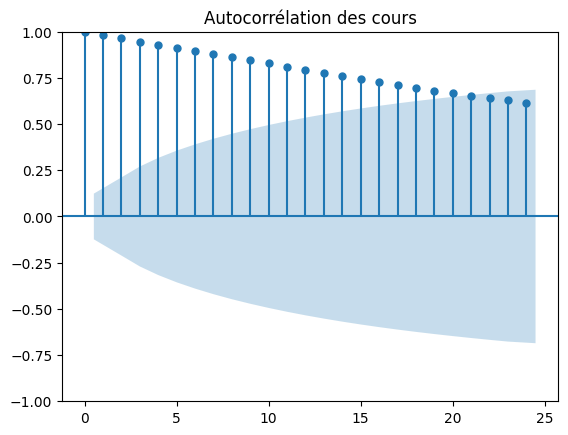

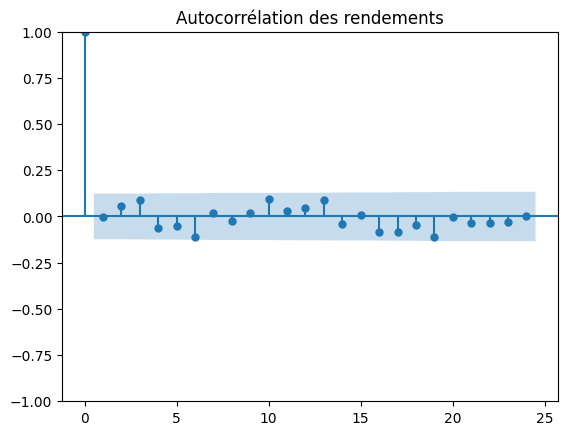

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(tsla_df['Close'], title='Autocorrélation des cours'),
plot_acf(tsla_df['Rendement (%)'], title='Autocorrélation des rendements')
plt.show()

For the price series, we observe that the process is autoregressive, meaning that the value at time $t$ depends on its past values. In this case, it appears to depend on up to 21 previous observations, as the autocorrelations up to lag $k = 21$ are significantly different from zero.

In contrast, for the returns series, we observe that none of the autocorrelations are significantly different from zero. Therefore, we can conclude that this process exhibits no memory.

##### 2.3. Normality

To assess the normality of both time series, we will first visualize their histograms, and then perform the **Shapiro–Wilk test**, which is specifically designed for this purpose.


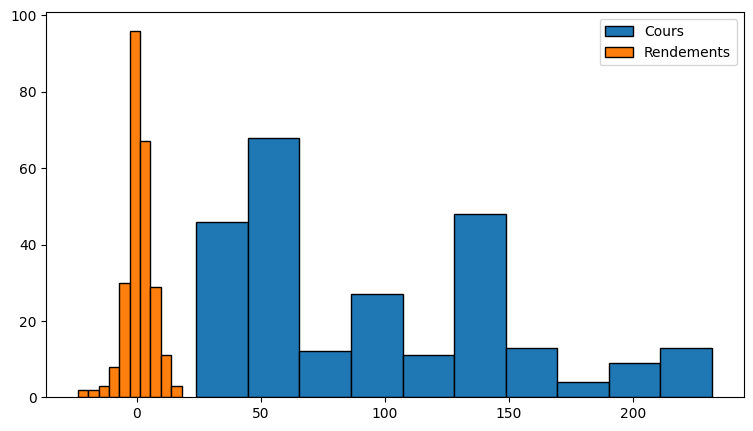

In [10]:
fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(111)
ax.hist(tsla_df['Close'], edgecolor='black', label='Cours')
ax.hist(tsla_df['Rendement (%)'], edgecolor='black', label="Rendements")
ax.legend(loc='upper right')
plt.show()

The histogram in blue represents the distribution of prices. It can be clearly observed that it does not resemble a normal distribution at all. In this case, visual inspection alone is sufficient to conclude that the price series is not normally distributed.

The histogram in yellow represents the distribution of returns. It appears to be closer to a normal distribution; however, it is essential to formally verify this assumption using a normality test.

**Test de normalité (Shapiro-Wilk) :**

In [11]:
from scipy.stats import shapiro 
shapiro(tsla_df['Close'])

ShapiroResult(statistic=np.float64(0.8994182093383671), pvalue=np.float64(6.650943648833554e-12))

The test results show that the p-value is equal to $6.5609 × 10^{-12}$, which is far below the $5\%$ significance level. Therefore, the null hypothesis of normality is rejected for the price series (i.e., it is highly unlikely to observe such data under the assumption of a normal distribution).


In [12]:
shapiro(tsla_df['Rendement (%)'])

ShapiroResult(statistic=np.float64(0.9502228367576668), pvalue=np.float64(1.4609015184472714e-07))

Similarly, the p-value obtained for the returns series is $1.46 × 10^{-07}$, which is far below the $5\%$ significance level. Therefore, the null hypothesis of normality is also rejected for the returns series.


##### Conclusion

The statistical analysis carried out in this section allowed us to compare the two series—prices and returns—and led to the conclusion that the returns series exhibits statistical properties that are more suitable for portfolio management and forecasting than the price series.
####  Portfolio Optimization
We now focus on applying Modern Portfolio Theory in order to optimize a portfolio composed of four assets: the stocks of the multinational companies Tesla, Apple, Netflix, and Amazon.
##### 1. Data Import
We begin by importing the daily historical prices of these stocks over the entire year 2021. This selection is based on the significant growth these assets experienced during that period.

[*********************100%***********************]  4 of 4 completed


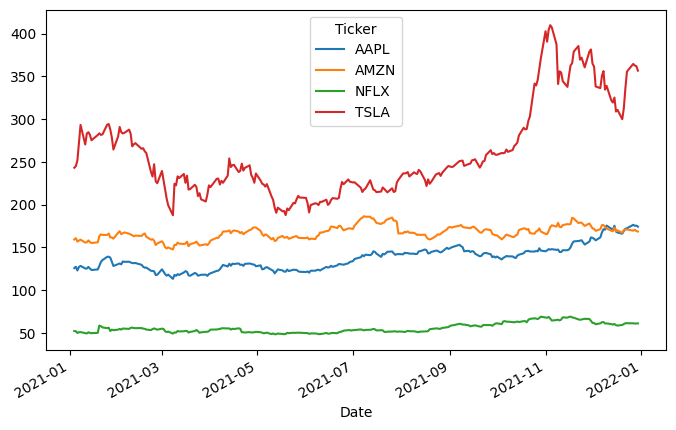

In [13]:
data = yf.download("TSLA AAPL NFLX AMZN", start="2021-01-01", 
                                           end ="2021-12-31")['Close']
data.plot(figsize=(8,5))
plt.show()

In [14]:
data.tail(10)

Ticker,AAPL,AMZN,NFLX,TSLA
Date,,,,
2021-12-16,168.562912,168.871002,59.105999,308.973328
2021-12-17,167.466949,170.017502,58.673000,310.856659
2021-12-20,166.106812,167.078995,59.374001,299.980011
2021-12-21,169.277267,170.417007,60.492001,312.843323
2021-12-22,171.870377,171.037003,61.424000,336.290009
2021-12-23,172.496643,171.068497,61.409000,355.666656
2021-12-27,176.459732,169.669495,61.312000,364.646667
2021-12-28,175.442032,170.660995,61.070999,362.823334
2021-12-29,175.530121,169.201004,61.054001,362.063324


In [15]:
data.describe() 

Ticker,AAPL,AMZN,NFLX,TSLA
count,251.000000,251.000000,251.000000,251.000000
mean,137.450292,167.195247,55.804151,259.630585
std,14.370090,8.018029,5.604423,53.528293
min,113.334129,147.597504,48.498001,187.666672
25%,125.404469,161.664246,51.229000,222.664993
50%,137.880219,167.078995,54.294998,243.256668
75%,145.462624,172.430496,59.889000,283.241653
max,176.459732,186.570496,69.168999,409.970001


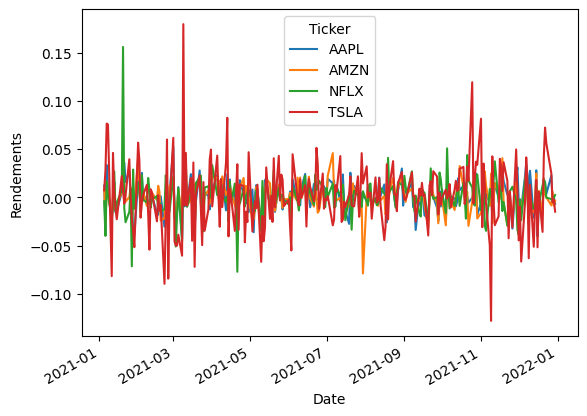

In [16]:
df=np.log(data/data.shift(1))
df.plot()
plt.ylabel('Rendements')
plt.show()

As observed in the graph above, the returns of the four assets all appear to be stationary. Consequently, the return series of our portfolio will also be stationary, regardless of the weights assigned to each asset.

##### 2. Portfolio Return and Risk

We define a function **`rand_weights`** that generates a random vector of weights $\pi$, such that each weight satisfies $ \pi_i \in [0,1] $ and the sum of all weights is equal to 1, i.e., $\sum \pi_i = 1 $.


In [17]:
def rand_weights(data):
    w = np.random.random(len(data.columns))
    return w/w.sum()

Next, we define the functions **`portfolio_return`** and **`portfolio_std`**, which compute respectively the expected return and the volatility (standard deviation) of the portfolio based on the assigned weight vector.


In [18]:
def portfolio_return(weights):
    return np.dot(weights, df.sum())

def portfolio_std(weights):
    return np.sqrt((weights.T @ df.cov()*df.count()[0] @ weights))

##### 3. Efficient Frontier
Next, we perform a simulation of 8,000 possible portfolio allocations in order to represent their positions on a risk–return plane.

In [19]:
weights_ = []
risks = []
returns = []
for i in range(8000):
    weights = rand_weights(df)
    returns.append(portfolio_return(weights))
    risks.append(portfolio_std(weights))
    weights_.append(weights)

C:\Users\abede\AppData\Local\Temp\ipykernel_21584\1051410199.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.sqrt((weights.T @ df.cov()*df.count()[0] @ weights))
C:\Users\abede\AppData\Local\Temp\ipykernel_21584\1051410199.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return np.sqrt((weights.T @ df.cov()*df.count()[0] @ weights))
C:\Users\abede\AppData\Local\Temp\ipykernel_21584\1051410199.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by pos

We store this set of portfolios in a dataset, specifying their returns, risks, and the weights allocated to each asset.

In [20]:
dict = {}
for c, ticker in enumerate(df.columns.tolist()):
    dict[ticker+' weight'] = [w[c] for w in weights_]
dict["Return"] = returns
dict["Risk"] = risks
portfolios = pd.DataFrame(dict)
portfolios

,AAPL weight,AMZN weight,NFLX weight,TSLA weight,Return,Risk
0,0.173264,0.263909,0.164194,0.398634,0.250036,0.294012
1,0.037399,0.161252,0.295069,0.506281,0.261754,0.334746
2,0.158409,0.427079,0.372350,0.042161,0.150730,0.221697
3,0.318720,0.235086,0.146069,0.300125,0.255242,0.265256
4,0.003237,0.207029,0.448488,0.341245,0.214180,0.287044
...,...,...,...,...,...,...
7995,0.459543,0.099193,0.193950,0.247314,0.280758,0.256688
7996,0.349236,0.054843,0.338087,0.257834,0.269011,0.261788
7997,0.197938,0.304127,0.408449,0.089486,0.180448,0.227887
7998,0.035496,0.355056,0.213145,0.396302,0.217113,0.292607


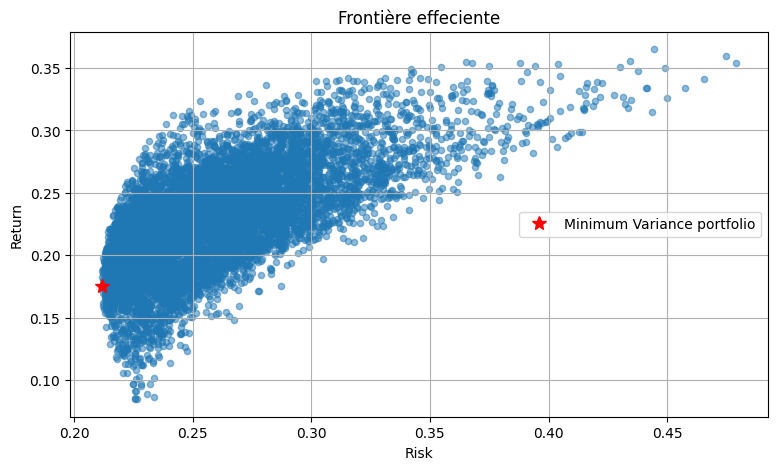

In [21]:
portfolios.plot.scatter("Risk", "Return", marker='o', grid=True, alpha=0.5, title='Frontière effeciente', figsize=(9,5))
plt.plot(min(risks), returns[risks.index(min(risks))], '*', markersize=10, c='r', label="Minimum Variance portfolio")
plt.legend(loc='right')
plt.show()

The representation of the different portfolio combinations forms a scatter plot that is convex with respect to risk. The set of optimal portfolios lies on the upper part of the efficient frontier, starting from the minimum-variance portfolio (represented by the red star).

#### 4. Performance Measurement

Performance measures are based on the **Capital Asset Pricing Model** (CAPM). We assume a model that explains returns as a function of market risk. Three classical measures can be distinguished:

* The Sharpe Ratio
* The Treynor Ratio
* Jensen’s Alpha

The first two ratios measure the excess return of the portfolio relative to the risk-free rate. Jensen’s Alpha and the Treynor Ratio rely on the systematic risk of the portfolio, obtained from the Security Market Line (SML). The Sharpe Ratio, on the other hand, is based on the total risk of the portfolio.

##### a. Sharpe Ratio

The Sharpe Ratio is based on the **Capital Market Line** (CML):

$$  E(R_p) = r_f + \frac{\sigma(R_p)}{\sigma(R_M)} \left( E(R_M) - r_f \right) $$

All efficient portfolios should lie on this line. The Sharpe Ratio is defined as:

$$ R_S = \frac{E(R_p) - r_f}{\sigma(R_p)} $$

where:
$R_p$ is the portfolio return,
$r_f$ is the risk-free rate,
$ \sigma(R_p)$ is the total risk (standard deviation) of the portfolio.

The Sharpe Ratio measures the excess return per unit of total risk. The higher the ratio, the better the portfolio’s performance.


In [22]:
Rf = 0.02 # risk free rate

sharpe_ratio = (portfolios['Return'] - Rf) / portfolios['Risk']

slope = max(sharpe_ratio)
x = np.linspace(0,0.5,50) 
y = Rf + slope*x 

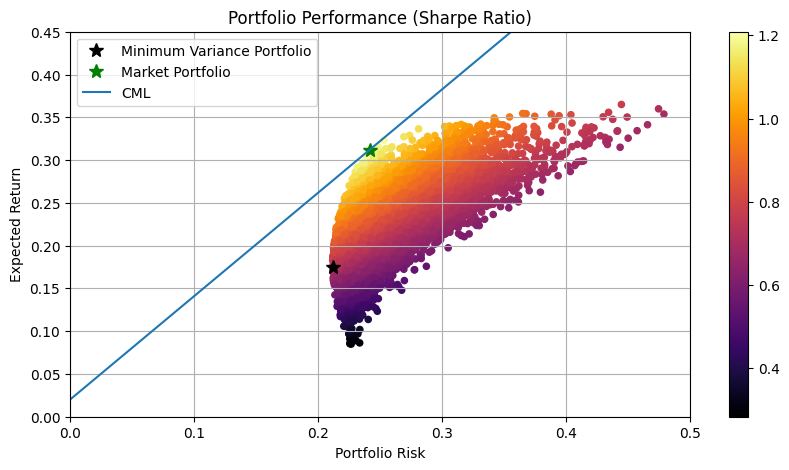

In [23]:
portfolios.plot.scatter(
    x="Risk",
    y="Return",
    marker='o',
    grid=True,
    c=sharpe_ratio,
    cmap='inferno',
    title='Portfolio Performance (Sharpe Ratio)',
    figsize=(10, 5)
)

# Portefeuille de variance minimale
plt.plot(
    min(risks),
    returns[risks.index(min(risks))],
    '*',
    markersize=10,
    c='k',
    label="Minimum Variance Portfolio"
)

# Portefeuille de marché (max Sharpe)
plt.plot(
    risks[sharpe_ratio.idxmax()],
    returns[sharpe_ratio.idxmax()],
    '*',
    markersize=10,
    c='g',
    label="Market Portfolio"
)

# Droite CML
plt.plot(x, y, label='CML')

plt.xlabel('Portfolio Risk')
plt.ylabel('Expected Return')
plt.ylim(0, 0.45)
plt.xlim(0, 0.5)

plt.legend()
plt.show()

The coloring of the portfolio cloud based on the Sharpe Ratio indicates that performance increases as we move toward the Capital Market Line (CML). Indeed, the CML is tangent to this cloud at the most efficient portfolio, which corresponds to the maximum Sharpe Ratio, also known as the market (tangency) portfolio.

##### b. Treynor Ratio

The Treynor Ratio measures the excess return of a portfolio adjusted for its systematic risk. It is defined as:

$$ R_T = \frac{E(R_p) - r_f}{\beta_p} $$

The higher the ratio, the better the portfolio’s performance.

In this study, we will use the S&P 500 index as the benchmark for our stock portfolio.

[*********************100%***********************]  1 of 1 completed


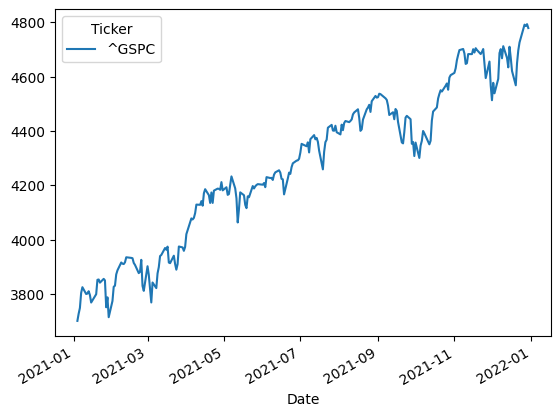

In [24]:
sp = yf.download('^GSPC', start="2021-01-01", end ="2021-12-31")['Close'] 
sp.plot()
plt.show()